# Diabetes Patient Clustering (Professional Report Notebook)

This notebook performs **unsupervised clustering** on cleaned clinical features to discover natural
patient subgroups. We follow a professional workflow:

1. Load and prepare the dataset
2. Engineer clinically meaningful ratio features
3. Preprocess (impute, encode, scale)
4. Compare scalers for distance-based clustering
5. Optional outlier filtering
6. Select the number of clusters (k)
7. Compare clustering algorithms
8. Visualize clusters in reduced space
9. Profile clusters for interpretation
10. Save cluster assignments for reporting


In [50]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler, QuantileTransformer
from sklearn.impute import SimpleImputer

from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering, SpectralClustering
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import NearestNeighbors

from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from sklearn.ensemble import IsolationForest
from sklearn.utils import resample

import warnings
warnings.filterwarnings("ignore")

try:
    import umap
    UMAP_AVAILABLE = True
except ImportError:
    UMAP_AVAILABLE = False

plt.style.use("seaborn-v0_8-whitegrid")

DATA_PATH = Path("../data/processed/diabetes_clean.csv")
TARGET_COL = "CLASS"
ID_COL_CANDIDATES = ["ID", "No_Pation"]
RANDOM_STATE = 42

# Optional runtime flags
RUN_TSNE = False
RUN_UMAP = UMAP_AVAILABLE
RUN_STABILITY = False
USE_OUTLIER_FILTER = True
FORCE_K = 3
FORCE_ALGO = "KMeans"


## 1. Load Data and Select Features

We load the cleaned dataset, remove ID-like columns, and drop the target label (`CLASS`) to keep the
analysis fully unsupervised. If labels exist, we keep a copy for *external validation* only (ARI/NMI).


In [51]:
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Missing data file: {DATA_PATH.resolve()}")

df = pd.read_csv(DATA_PATH)

# Remove ID columns if present
id_cols = [c for c in ID_COL_CANDIDATES if c in df.columns]
if id_cols:
    df = df.drop(columns=id_cols)

# Save labels for evaluation, then drop for clustering
if TARGET_COL in df.columns:
    y_true = df[TARGET_COL].copy()
    df = df.drop(columns=[TARGET_COL])
else:
    y_true = None

X = df.copy()

print(f"Rows: {len(X):,} | Columns: {len(X.columns)}")


Rows: 1,000 | Columns: 11


## 2. Feature Engineering (Clinical Ratios)

Derived ratios can separate clinically meaningful phenotypes better than raw values.
We add a small set of standard risk ratios when the required columns exist.


In [52]:
ratio_defs = [
    ("TG", "HDL", "TG_HDL_ratio"),
    ("LDL", "HDL", "LDL_HDL_ratio"),
    ("Urea", "Cr", "Urea_Cr_ratio"),
]

for num, denom, name in ratio_defs:
    if num in X.columns and denom in X.columns:
        X[name] = X[num] / X[denom].replace(0, np.nan)

# Replace inf with NaN so the imputer can handle it
X = X.replace([np.inf, -np.inf], np.nan)

num_cols = X.select_dtypes(include="number").columns.tolist()
cat_cols = X.select_dtypes(exclude="number").columns.tolist()

print(f"Numeric features: {len(num_cols)}")
print(f"Categorical features: {len(cat_cols)}")


Numeric features: 13
Categorical features: 1


## 3. Preprocessing

K-Means and most distance-based methods are sensitive to feature scale. We therefore:
- **Impute** missing values (median for numeric, most-frequent for categorical)
- **Scale** numeric features
- **One-hot encode** categorical features

We define a reusable preprocessor so we can compare scalers objectively.


In [53]:
def make_preprocessor(scaler):
    numeric_pipe = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", scaler),
        ]
    )

    # Compatibility across scikit-learn versions
    try:
        onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        onehot = OneHotEncoder(handle_unknown="ignore", sparse=False)

    categorical_pipe = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", onehot),
        ]
    )

    return ColumnTransformer(
        transformers=[
            ("num", numeric_pipe, num_cols),
            ("cat", categorical_pipe, cat_cols),
        ],
        remainder="drop",
    )


## 4. Compare Scalers (Standard vs Robust vs Quantile)

We compare scalers using K-Means and select the scaler that yields the best separation
(based on the maximum silhouette score across candidate k values).


In [54]:
scalers = {
    "StandardScaler": StandardScaler(),
    "RobustScaler": RobustScaler(),
    "QuantileTransformer": QuantileTransformer(output_distribution="normal", random_state=RANDOM_STATE),
}

k_range = range(2, min(10, len(X) - 1) + 1)

scaler_results = []
for name, scaler in scalers.items():
    preprocessor = make_preprocessor(scaler)
    X_scaled = preprocessor.fit_transform(X)

    scores = []
    for k in k_range:
        labels = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20).fit_predict(X_scaled)
        scores.append(silhouette_score(X_scaled, labels))

    scaler_results.append(
        {
            "scaler": name,
            "best_silhouette": float(np.max(scores)),
        }
    )

scaler_df = pd.DataFrame(scaler_results).sort_values(by="best_silhouette", ascending=False)

best_scaler_name = scaler_df.iloc[0]["scaler"]
print(f"Best scaler by silhouette: {best_scaler_name}")

preprocessor = make_preprocessor(scalers[best_scaler_name])
X_scaled = preprocessor.fit_transform(X)

display(scaler_df)


Best scaler by silhouette: RobustScaler


,scaler,best_silhouette
1,RobustScaler,0.721203
0,StandardScaler,0.179340
2,QuantileTransformer,0.138619


## 5. Optional Outlier Filtering

Small clusters can sometimes represent extreme outliers rather than real subgroups.
We optionally detect outliers using IsolationForest and remove them **before** clustering.
We keep indices so outliers can be labeled as `-1` later.


In [55]:
if USE_OUTLIER_FILTER:
    iso = IsolationForest(contamination=0.05, random_state=RANDOM_STATE)
    outlier_flag = iso.fit_predict(X_scaled)
    inlier_mask = outlier_flag == 1

    print(f"Outliers detected: {(~inlier_mask).sum()} / {len(inlier_mask)}")
else:
    inlier_mask = np.ones(len(X), dtype=bool)

X_used = X.loc[inlier_mask].copy()
X_scaled_used = X_scaled[inlier_mask]

if y_true is not None:
    y_true_used = y_true.loc[X_used.index]
else:
    y_true_used = None


Outliers detected: 50 / 1000


## 6. Select the Number of Clusters (k)

We evaluate `k` using:
- **Elbow (inertia)**: diminishing returns in within-cluster variance
- **Silhouette score**: separation quality (higher is better)

We select the best k by maximum silhouette score.


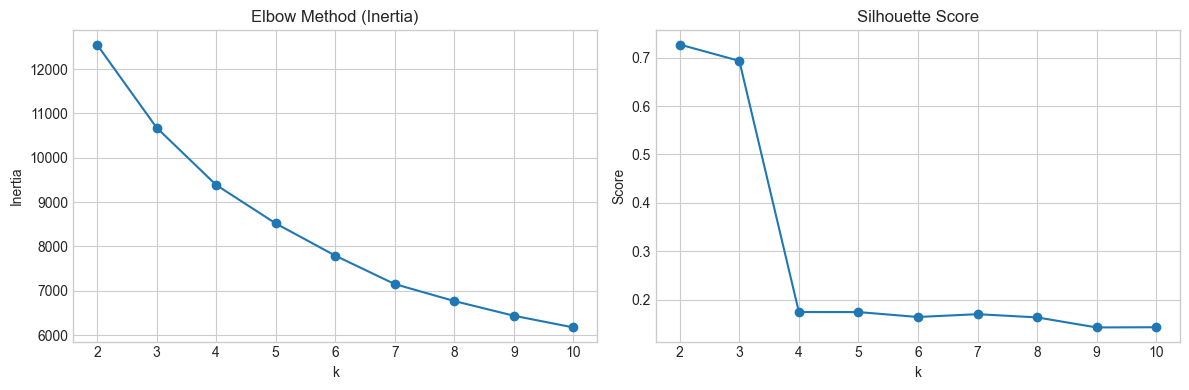

Best k by silhouette: 2
Using k: 3


In [56]:
n_samples = X_scaled_used.shape[0]
if n_samples < 2:
    raise ValueError("Not enough samples for clustering.")

max_k = min(10, n_samples - 1)
if max_k < 2:
    raise ValueError("Not enough samples to try k>=2.")

k_values = range(2, max_k + 1)

inertia = []
silhouette = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
    labels = km.fit_predict(X_scaled_used)
    inertia.append(km.inertia_)
    silhouette.append(silhouette_score(X_scaled_used, labels))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(k_values, inertia, marker="o")
ax[0].set_title("Elbow Method (Inertia)")
ax[0].set_xlabel("k")
ax[0].set_ylabel("Inertia")

ax[1].plot(k_values, silhouette, marker="o")
ax[1].set_title("Silhouette Score")
ax[1].set_xlabel("k")
ax[1].set_ylabel("Score")

plt.tight_layout()
plt.show()

best_k = FORCE_K if FORCE_K is not None else k_values[int(np.argmax(silhouette))]
print(f"Best k by silhouette: {k_values[int(np.argmax(silhouette))]}")
print(f"Using k: {best_k}")


## 7. Compare Clustering Algorithms

We compare multiple algorithms using internal metrics:
- **Silhouette** (higher is better)
- **Calinski–Harabasz** (higher is better)
- **Davies–Bouldin** (lower is better)

If ground-truth labels exist (`CLASS`), we also report **ARI** and **NMI** as external validation.


In [57]:
def evaluate_labels(X, labels):
    # Exclude noise points for DBSCAN
    mask = labels != -1
    n_clusters = len(set(labels[mask]))

    if n_clusters < 2:
        return np.nan, np.nan, np.nan, n_clusters, (1 - mask.mean())

    X_eval = X[mask]
    y_eval = labels[mask]

    sil = silhouette_score(X_eval, y_eval)
    ch = calinski_harabasz_score(X_eval, y_eval)
    db = davies_bouldin_score(X_eval, y_eval)
    noise_pct = 1 - mask.mean()
    return sil, ch, db, n_clusters, noise_pct


def estimate_dbscan_eps(X, k=5, percentile=95):
    nbrs = NearestNeighbors(n_neighbors=k).fit(X)
    distances, _ = nbrs.kneighbors(X)
    k_dist = np.sort(distances[:, -1])
    return float(np.percentile(k_dist, percentile))


def evaluate_clustering_algorithms(X, y_true=None, n_clusters=3):
    results = []

    algorithms = {
        "KMeans": KMeans(n_clusters=n_clusters, random_state=RANDOM_STATE, n_init=20),
        "GMM": GaussianMixture(n_components=n_clusters, random_state=RANDOM_STATE),
        "Agglomerative": AgglomerativeClustering(n_clusters=n_clusters, linkage="ward"),
    }

    # Spectral can be expensive on large datasets
    if X.shape[0] <= 2000:
        algorithms["Spectral"] = SpectralClustering(
            n_clusters=n_clusters,
            random_state=RANDOM_STATE,
            affinity="nearest_neighbors",
        )

    # DBSCAN with heuristic eps
    dbscan_eps = estimate_dbscan_eps(X)
    algorithms["DBSCAN"] = DBSCAN(eps=dbscan_eps, min_samples=5)

    for name, algo in algorithms.items():
        if name == "GMM":
            labels = algo.fit_predict(X)
        else:
            labels = algo.fit_predict(X)

        sil, ch, db, n_clusters_found, noise_pct = evaluate_labels(X, labels)

        row = {
            "algorithm": name,
            "silhouette": sil,
            "calinski_harabasz": ch,
            "davies_bouldin": db,
            "n_clusters": n_clusters_found,
            "noise_pct": noise_pct,
        }

        if y_true is not None and n_clusters_found > 1:
            row["ARI"] = adjusted_rand_score(y_true, labels)
            row["NMI"] = normalized_mutual_info_score(y_true, labels)

        results.append(row)

    return pd.DataFrame(results)


algo_results = evaluate_clustering_algorithms(X_scaled_used, y_true_used, n_clusters=best_k)

# Select best algorithm by silhouette (fallback to KMeans if all NaN)
valid = algo_results.dropna(subset=["silhouette"])
if len(valid) == 0:
    best_algo = "KMeans"
else:
    best_algo = valid.sort_values(by="silhouette", ascending=False).iloc[0]["algorithm"]

if FORCE_ALGO is not None:
    best_algo = FORCE_ALGO
print(f"Best algorithm by silhouette: {best_algo}")

display(algo_results.sort_values(by="silhouette", ascending=False))


Best algorithm by silhouette: KMeans


,algorithm,silhouette,calinski_harabasz,davies_bouldin,n_clusters,noise_pct,ARI,NMI
0,KMeans,0.693332,608.052965,0.462874,3,0.000000,-0.059869,0.016199
2,Agglomerative,0.679954,595.304810,0.515134,3,0.000000,-0.044898,0.011282
4,DBSCAN,0.606422,420.841377,0.683963,3,0.029474,-0.067296,0.016889
3,Spectral,0.572418,512.548557,0.772940,3,0.000000,-0.053006,0.012380
1,GMM,0.034284,52.447024,2.943499,3,0.000000,-0.007932,0.019119


## 8. Fit Final Model and Assign Clusters

We fit the selected algorithm on the processed feature matrix. If outlier filtering was applied,
we keep those points labeled as `-1` for clarity in downstream analysis.


In [ ]:
if best_algo == "KMeans":
    final_model = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=20)
    labels = final_model.fit_predict(X_scaled_used)
elif best_algo == "GMM":
    final_model = GaussianMixture(n_components=best_k, random_state=RANDOM_STATE)
    labels = final_model.fit_predict(X_scaled_used)
elif best_algo == "Agglomerative":
    final_model = AgglomerativeClustering(n_clusters=best_k, linkage="ward")
    labels = final_model.fit_predict(X_scaled_used)
elif best_algo == "Spectral":
    final_model = SpectralClustering(
        n_clusters=best_k,
        random_state=RANDOM_STATE,
        affinity="nearest_neighbors",i
    )
    labels = final_model.fit_predict(X_scaled_used)
elif best_algo == "DBSCAN":
    eps = estimate_dbscan_eps(X_scaled_used)
    final_model = DBSCAN(eps=eps, min_samples=5)
    labels = final_model.fit_predict(X_scaled_used)
else:
    raise ValueError(f"Unknown algorithm: {best_algo}")

clustered_all = X.copy()
clustered_all["cluster"] = -1
clustered_all.loc[X_used.index, "cluster"] = labels

print(clustered_all["cluster"].value_counts().sort_index())


cluster
-1     50
 0    901
 1     44
 2      5
Name: count, dtype: int64


## 9. Visualization in Reduced Space

We project the feature space into 2D for visualization. This does **not** change the clustering,
but helps interpret overlap and separation visually.


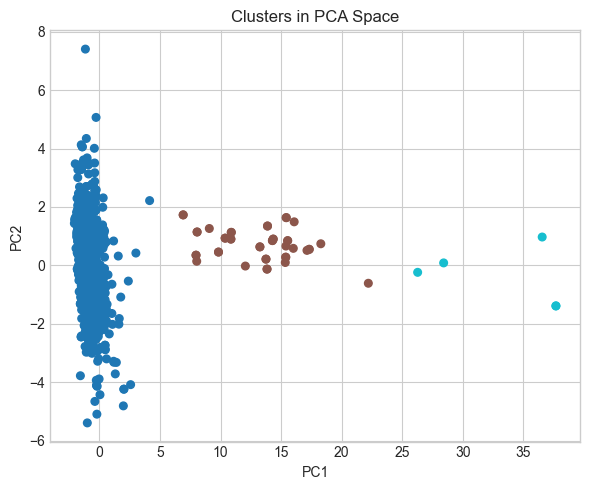

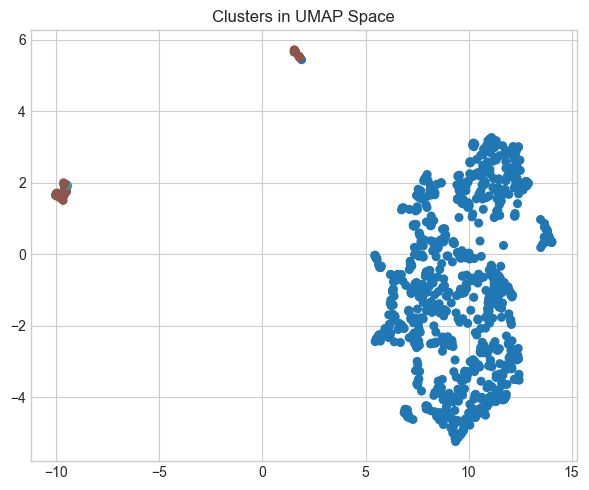

In [59]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled_used)

plt.figure(figsize=(6, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap="tab10", s=30)
plt.title("Clusters in PCA Space")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

if RUN_TSNE:
    tsne = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=30)
    X_tsne = tsne.fit_transform(X_scaled_used)
    plt.figure(figsize=(6, 5))
    plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels, cmap="tab10", s=30)
    plt.title("Clusters in t-SNE Space")
    plt.tight_layout()
    plt.show()

if RUN_UMAP and UMAP_AVAILABLE:
    reducer = umap.UMAP(random_state=RANDOM_STATE)
    X_umap = reducer.fit_transform(X_scaled_used)
    plt.figure(figsize=(6, 5))
    plt.scatter(X_umap[:, 0], X_umap[:, 1], c=labels, cmap="tab10", s=30)
    plt.title("Clusters in UMAP Space")
    plt.tight_layout()
    plt.show()


## 10. Cluster Profiling (Interpretation)

We summarize the mean values of numeric features per cluster.
Look for clear differences in HbA1c, BMI, lipids, and renal markers to interpret clinical subgroups.


In [60]:
clustered = clustered_all[clustered_all["cluster"] != -1].copy()

cluster_summary = clustered.groupby("cluster")[num_cols].mean()

print("Cluster sizes:")
print(clustered["cluster"].value_counts().sort_index())

display(cluster_summary)


Cluster sizes:
cluster
0    901
1     44
2      5
Name: count, dtype: int64


,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,TG_HDL_ratio,LDL_HDL_ratio,Urea_Cr_ratio
cluster,,,,,,,,,,,,,
0,53.894562,4.884129,62.896781,8.236249,4.814983,2.282464,1.181887,2.565094,1.037070,29.349168,2.211941,2.475864,0.081147
1,44.909091,4.763250,70.568182,8.204545,4.606818,1.729773,1.116136,2.837273,12.086364,33.134773,1.632698,2.620473,0.068552
2,55.000000,4.564000,63.200000,8.720000,5.464000,3.620000,0.926000,3.040000,28.360000,32.086000,4.094763,3.328827,0.079748


## 11. (Optional) Cluster Stability Check

We estimate stability by re-running clustering on bootstrap samples.
This helps confirm whether cluster assignments are robust or fragile.


In [61]:
if RUN_STABILITY:
    n_iterations = 30
    n_clusters = best_k
    stability_scores = []

    for i in range(n_iterations):
        X_boot = resample(X_scaled_used, replace=True, random_state=RANDOM_STATE + i)
        km = KMeans(n_clusters=n_clusters, random_state=RANDOM_STATE + i, n_init=10)
        labels_boot = km.fit_predict(X_boot)
        sil = silhouette_score(X_boot, labels_boot)
        stability_scores.append(sil)

    print(f"Silhouette stability (mean ± std): {np.mean(stability_scores):.3f} ± {np.std(stability_scores):.3f}")


## 12. Save Cluster Assignments

We save all rows with a `cluster` column. If outlier filtering was applied,
those outliers are labeled as `-1`.


In [62]:
OUTPUT_PATH = Path("../data/processed/diabetes_clusters.csv")
clustered_all.to_csv(OUTPUT_PATH, index=False)
print(f"Saved cluster assignments to: {OUTPUT_PATH.resolve()}")


Saved cluster assignments to: /Users/abhaydhakal/Documents/diabetes_prediction/data/processed/diabetes_clusters.csv
